In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!nvidia-smi

Thu May  7 18:15:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install yfinance transformers torch bitsandbytes accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

# Use the 50 most liquid stocks in the S&P 500—no need to scrape Wikipedia
tickers = [
    'AAPL','MSFT','NVDA','AMZN','META','GOOGL','TSLA','AVGO','JPM','LLY',
    'V','UNH','XOM','MA','JNJ','PG','HD','MRK','ABBV','COST',
    'CVX','BAC','NFLX','KO','PEP','TMO','MCD','CSCO','ADBE','WMT',
    'CRM','ACN','LIN','DHR','ABT','NKE','TXN','PM','NEE','RTX',
    'ORCL','QCOM','HON','UPS','IBM','GE','CAT','BA','AMGN','GS'
]

screen_start   = "2025-09-01"
screen_end     = "2025-12-31"
backtest_start = "2026-01-01"
backtest_end   = "2026-04-30"

print(f"downloading {len(tickers)} tickers...")
price_screen = yf.download(tickers, start=screen_start, end=screen_end,
                            auto_adjust=True, progress=False)['Close']

momentum = (price_screen.iloc[-1] / price_screen.iloc[0] - 1).dropna()
top15 = momentum.nlargest(15)
candidate_tickers = top15.index.tolist()

print("\n=== Top 15 by momentum ===")
for t, m in top15.items():
    print(f"  {t}: {m*100:.1f}%")

downloading 50 tickers...

=== Top 15 by momentum ===
  GOOGL: 48.7%
  LLY: 47.1%
  CAT: 39.2%
  TSLA: 38.0%
  MRK: 26.4%
  IBM: 25.8%
  GS: 21.6%
  TMO: 19.9%
  AAPL: 19.0%
  UPS: 18.9%
  AVGO: 17.7%
  JNJ: 16.9%
  RTX: 16.9%
  AMGN: 15.4%
  CSCO: 14.9%


In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import json, re

# ── Load Model (the same as Assignment 2) ────────────────────────────────
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
print("Model loaded successfully")

# ── Sentiment Scoring Function (reused from Assignment 2)────────────────────────────
SYSTEM_PROMPT = """You are a quantitative financial analyst. 
Analyze the news and output ONE sentence of analysis, then output ONLY a JSON object on the last line.
Schema: {"sentiment_score": <integer -2 to 2>, "direction": "<Bullish|Neutral|Bearish>", "confidence": <float 0.0 to 1.0>}
sentiment_score: +2=strongly bullish, +1=mildly bullish, 0=neutral, -1=mildly bearish, -2=strongly bearish"""

def get_signal(news_text: str) -> dict:
    """Input news text; return structured sentiment signals."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"News: {news_text[:800]}"}
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )
    
    # Parsing JSON
    json_matches = re.findall(r'\{[^{}]+\}', response)
    if json_matches:
        try:
            signal = json.loads(json_matches[-1])
            signal['note'] = 'llm_output'
            signal['reasoning'] = response.split('{')[0].strip()
            return signal
        except:
            pass
    
    # fallback：Keyword Analysis
    pos = sum(response.lower().count(w) for w in ['growth','beat','strong','positive','bullish'])
    neg = sum(response.lower().count(w) for w in ['miss','weak','decline','negative','bearish'])
    score = min(2, max(-2, pos - neg))
    return {
        "sentiment_score": score,
        "direction": "Bullish" if score>0 else ("Bearish" if score<0 else "Neutral"),
        "confidence": 0.3,
        "note": "keyword_fallback",
        "reasoning": "fallback"
    }

# ── Retrieve News and Batch Rate ────────────────────────────────────────
# Using yfinance's built-in news feature
def get_stock_news(ticker: str) -> str:
    """Retrieve the latest stock news and consolidate it into a single block of text."""
    try:
        stock = yf.Ticker(ticker)
        news = stock.news[:5]  # Retrieve the 5 most recent items
        headlines = []
        for item in news:
            if 'title' in item:
                headlines.append(item['title'])
        return " | ".join(headlines) if headlines else f"{ticker} stock performance"
    except:
        return f"{ticker} financial news"

print("\n=== Assign Sentiment Scores to Candidate Stocks ===")
sentiment_results = {}

for ticker in candidate_tickers:
    news_text = get_stock_news(ticker)
    signal = get_signal(news_text)
    sentiment_results[ticker] = signal
    direction_emoji = "🟢" if signal['direction']=='Bullish' else ("🔴" if signal['direction']=='Bearish' else "⚪")
    print(f"  {ticker}: {direction_emoji} {signal['direction']} | score={signal['sentiment_score']} | conf={signal['confidence']:.2f}")

# Organize into a DataFrame
sentiment_df = pd.DataFrame(sentiment_results).T
sentiment_df.index.name = 'ticker'
print("\nSentiment Scoring Complete")
print(sentiment_df[['sentiment_score','direction','confidence','note']])

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully

=== Assign Sentiment Scores to Candidate Stocks ===
  GOOGL: ⚪ Neutral | score=1 | conf=0.65
  LLY: ⚪ Neutral | score=0 | conf=0.67
  CAT: ⚪ Neutral | score=0 | conf=0.50
  TSLA: ⚪ Neutral | score=1 | conf=0.65
  MRK: ⚪ Neutral | score=1 | conf=0.65
  IBM: 🟢 Bullish | score=1 | conf=0.30
  GS: 🟢 Bullish | score=1 | conf=0.85
  TMO: ⚪ Neutral | score=0 | conf=0.30
  AAPL: 🟢 Bullish | score=1 | conf=0.95
  UPS: 🟢 Bullish | score=1 | conf=0.85
  AVGO: ⚪ Neutral | score=0 | conf=0.50
  JNJ: 🟢 Bullish | score=1 | conf=0.30
  RTX: 🟢 Bullish | score=1 | conf=0.30
  AMGN: 🟢 Bullish | score=1 | conf=0.30
  CSCO: ⚪ Neutral | score=0 | conf=0.65

Sentiment Scoring Complete
       sentiment_score direction confidence              note
ticker                                                       
GOOGL                1   Neutral     0.6475        llm_output
LLY                  0   Neutral       0.67        llm_output
CAT                  0   Neutral        0.5        llm

In [7]:
# ── Sentiment Filtering + Weight Calculation ───────────────────────────────────────
# Rule 1: Exclude high-confidence Bearish signals (direction = Bearish and confidence > 0.6)
# Rule 2: Adjust Weights Using Sentiment Scores

def compute_weights(sentiment_df: pd.DataFrame) -> pd.Series:
    """Calculating Portfolio Weights Based on Sentiment Scores"""
    df = sentiment_df.copy()
    
    # Exclude High-Confidence Bearish Signals
    mask_bearish_strong = (df['direction'] == 'Bearish') & (df['confidence'] > 0.6)
    df_filtered = df[~mask_bearish_strong].copy()
    
    print(f"\nAfter excluding strongly bearish views there remains：{len(df_filtered)}/{len(df)} stocks")
    if mask_bearish_strong.any():
        print(f"  Eliminate：{list(df[mask_bearish_strong].index)}")
    
    # Emotional Weight: Base = 1. Each +1 point increases the weight by 20%; each -1 point decreases it by 10%
    df_filtered['raw_weight'] = df_filtered['sentiment_score'].apply(
        lambda s: 1 + s * 0.2 if s >= 0 else 1 + s * 0.1
    )
    df_filtered['raw_weight'] = df_filtered['raw_weight'].clip(lower=0.1)
    
    # Normalization
    weights = df_filtered['raw_weight'] / df_filtered['raw_weight'].sum()
    return weights

portfolio_weights = compute_weights(sentiment_df)
final_tickers = portfolio_weights.index.tolist()

print("\n=== Final Portfolio Weights ===")
for t, w in portfolio_weights.sort_values(ascending=False).items():
    print(f"  {t}: {w*100:.1f}%")


After excluding strongly bearish views there remains：15/15 stocks

=== Final Portfolio Weights ===
  GOOGL: 7.1%
  MRK: 7.1%
  TSLA: 7.1%
  IBM: 7.1%
  GS: 7.1%
  UPS: 7.1%
  AAPL: 7.1%
  AMGN: 7.1%
  JNJ: 7.1%
  RTX: 7.1%
  CAT: 5.9%
  LLY: 5.9%
  TMO: 5.9%
  AVGO: 5.9%
  CSCO: 5.9%


Download backtesting period data（2026-01-01 to 2026-04-30）...

=== AI Portfolio (Momentum + FinGPT Sentiment) ===
  Total Return:      1.28%
  Annualized Return: 4.08%
  Annualized Vol:    15.90%
  Sharpe Ratio:      0.26
  Max Drawdown:      -10.52%
  Win Rate (daily):  48.8%

=== SPY Benchmark ===
  Total Return:      4.44%
  Annualized Return: 14.68%
  Annualized Vol:    14.22%
  Sharpe Ratio:      1.03
  Max Drawdown:      -8.88%
  Win Rate (daily):  51.2%

>>> Alpha vs SPY: -3.17%
>>> ❌ Underperformed SPY


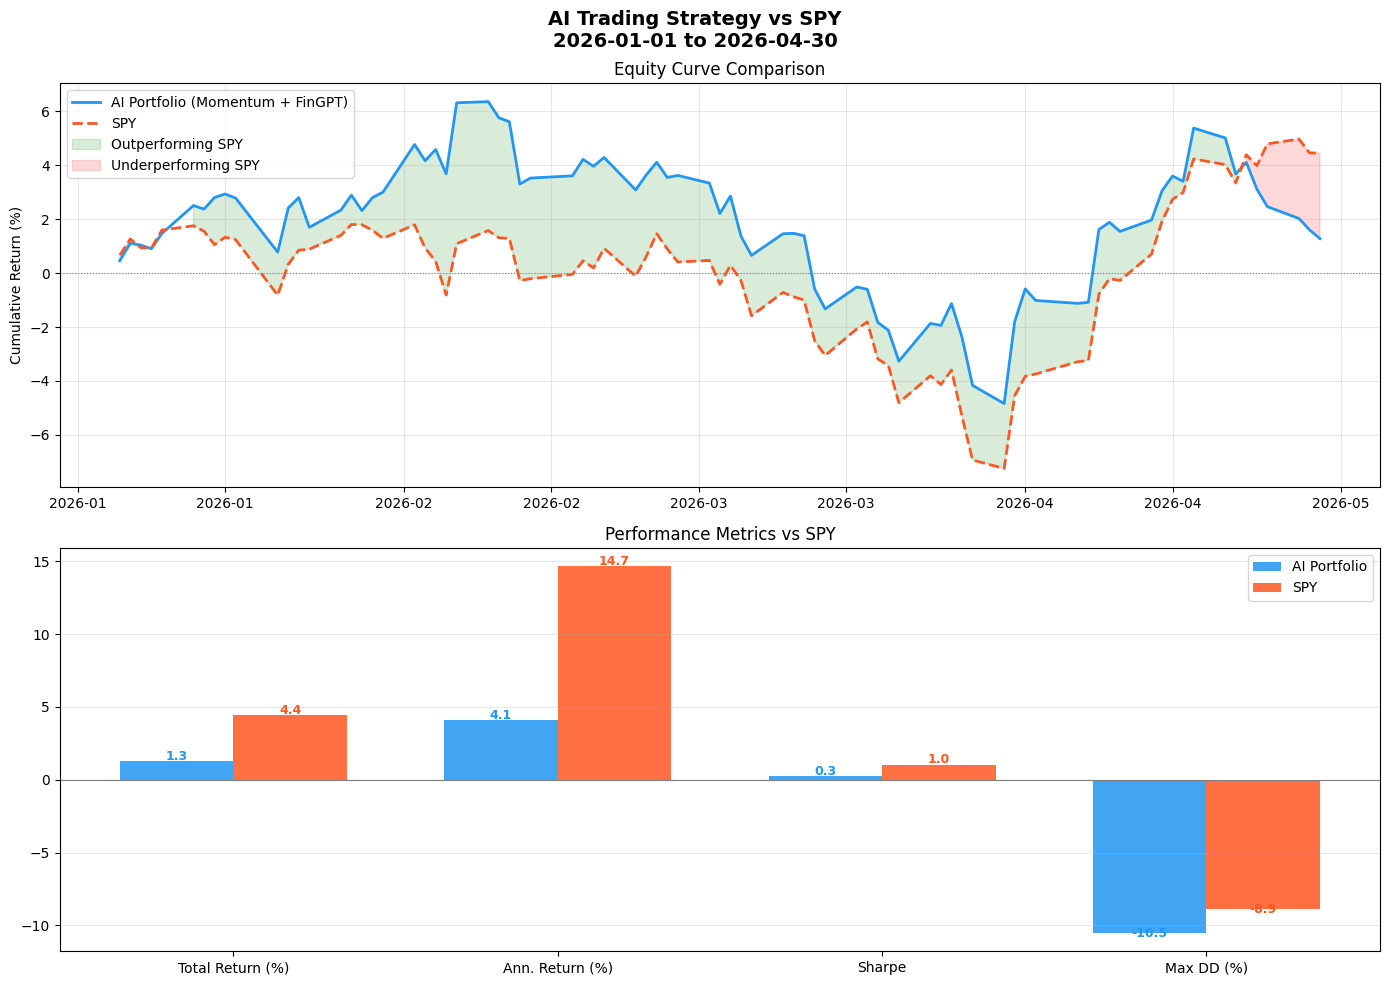

The chart has been saved as strategy_vs_spy.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Download price data for the backtesting period ────────────────────────────────────────
print("Download backtesting period data（2026-01-01 to 2026-04-30）...")
all_tickers = final_tickers + ['SPY']
price_backtest = yf.download(
    all_tickers, start=backtest_start, end=backtest_end,
    auto_adjust=True, progress=False
)['Close'].dropna(how='all')

# ── Calculate Portfolio Returns ──────────────────────────────────────────────
# Daily Return Rate
returns = price_backtest.pct_change().dropna()

# Portfolio Return = Sum of Weighted Daily Returns
portfolio_returns = returns[final_tickers].multiply(
    portfolio_weights, axis=1
).sum(axis=1)

spy_returns = returns['SPY']

# Cumulative Return Curve (Starting from 1)
portfolio_cumret = (1 + portfolio_returns).cumprod()
spy_cumret       = (1 + spy_returns).cumprod()

# ── Performance Metric Calculation ──────────────────────────────────────────────
def compute_metrics(daily_returns: pd.Series, label: str) -> dict:
    cum = (1 + daily_returns).cumprod()
    total_ret    = cum.iloc[-1] - 1
    ann_ret      = (1 + total_ret) ** (252 / len(daily_returns)) - 1
    ann_vol      = daily_returns.std() * np.sqrt(252)
    sharpe       = ann_ret / ann_vol if ann_vol > 0 else 0
    peak         = cum.cummax()
    max_dd       = ((cum - peak) / peak).min()
    win_rate     = (daily_returns > 0).mean()
    
    print(f"\n=== {label} ===")
    print(f"  Total Return:      {total_ret*100:.2f}%")
    print(f"  Annualized Return: {ann_ret*100:.2f}%")
    print(f"  Annualized Vol:    {ann_vol*100:.2f}%")
    print(f"  Sharpe Ratio:      {sharpe:.2f}")
    print(f"  Max Drawdown:      {max_dd*100:.2f}%")
    print(f"  Win Rate (daily):  {win_rate*100:.1f}%")
    
    return {'total_ret':total_ret,'ann_ret':ann_ret,'sharpe':sharpe,
            'max_dd':max_dd,'win_rate':win_rate,'vol':ann_vol}

m_port = compute_metrics(portfolio_returns, "AI Portfolio (Momentum + FinGPT Sentiment)")
m_spy  = compute_metrics(spy_returns,       "SPY Benchmark")

alpha = m_port['total_ret'] - m_spy['total_ret']
print(f"\n>>> Alpha vs SPY: {alpha*100:+.2f}%")
print(f">>> {'✅ Beat SPY' if alpha > 0 else '❌ Underperformed SPY'}")

# ── Drawing ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('AI Trading Strategy vs SPY\n2026-01-01 to 2026-04-30', 
             fontsize=14, fontweight='bold')

# Figure 1: Cumulative Return Curve
ax1 = axes[0]
ax1.plot(portfolio_cumret.index, (portfolio_cumret-1)*100, 
         color='#2196F3', lw=2, label='AI Portfolio (Momentum + FinGPT)')
ax1.plot(spy_cumret.index,       (spy_cumret-1)*100,
         color='#FF5722', lw=2, label='SPY', linestyle='--')
ax1.axhline(0, color='gray', lw=0.8, linestyle=':')
ax1.fill_between(portfolio_cumret.index, 
                 (portfolio_cumret-1)*100, (spy_cumret-1)*100,
                 where=(portfolio_cumret >= spy_cumret),
                 alpha=0.15, color='green', label='Outperforming SPY')
ax1.fill_between(portfolio_cumret.index,
                 (portfolio_cumret-1)*100, (spy_cumret-1)*100,
                 where=(portfolio_cumret < spy_cumret),
                 alpha=0.15, color='red', label='Underperforming SPY')
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_title('Equity Curve Comparison')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Figure 2：Summary metrics bar chart
ax2 = axes[1]
metrics_labels = ['Total Return (%)', 'Ann. Return (%)', 'Sharpe', 'Max DD (%)']
port_vals = [m_port['total_ret']*100, m_port['ann_ret']*100, 
             m_port['sharpe'], m_port['max_dd']*100]
spy_vals  = [m_spy['total_ret']*100,  m_spy['ann_ret']*100,
             m_spy['sharpe'],  m_spy['max_dd']*100]

x = np.arange(len(metrics_labels))
w = 0.35
ax2.bar(x - w/2, port_vals, w, label='AI Portfolio', color='#2196F3', alpha=0.85)
ax2.bar(x + w/2, spy_vals,  w, label='SPY',          color='#FF5722', alpha=0.85)
for i, (pv, sv) in enumerate(zip(port_vals, spy_vals)):
    ax2.text(i-w/2, pv + (0.1 if pv>=0 else -0.3), f'{pv:.1f}',
             ha='center', fontsize=9, color='#2196F3', fontweight='bold')
    ax2.text(i+w/2, sv + (0.1 if sv>=0 else -0.3), f'{sv:.1f}',
             ha='center', fontsize=9, color='#FF5722', fontweight='bold')
ax2.axhline(0, color='gray', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_labels)
ax2.set_title('Performance Metrics vs SPY')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('strategy_vs_spy.png', dpi=150, bbox_inches='tight')
plt.show()
print("The chart has been saved as strategy_vs_spy.png")

In [10]:
# ── Generating Results Comparison Table ────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': ['Total Return', 'Annualized Return', 'Volatility', 
               'Sharpe Ratio', 'Max Drawdown', 'Daily Win Rate'],
    'AI Portfolio': [
        f"{m_port['total_ret']*100:.2f}%",
        f"{m_port['ann_ret']*100:.2f}%",
        f"{m_port['vol']*100:.2f}%",
        f"{m_port['sharpe']:.2f}",
        f"{m_port['max_dd']*100:.2f}%",
        f"{m_port['win_rate']*100:.1f}%",
    ],
    'SPY': [
        f"{m_spy['total_ret']*100:.2f}%",
        f"{m_spy['ann_ret']*100:.2f}%",
        f"{m_spy['vol']*100:.2f}%",
        f"{m_spy['sharpe']:.2f}",
        f"{m_spy['max_dd']*100:.2f}%",
        f"{m_spy['win_rate']*100:.1f}%",
    ],
    'Winner': [
        'Portfolio' if m_port['total_ret']>m_spy['total_ret'] else 'SPY',
        'Portfolio' if m_port['ann_ret']>m_spy['ann_ret'] else 'SPY',
        'SPY' if m_port['vol']<m_spy['vol'] else 'Portfolio',  # 越低越好
        'Portfolio' if m_port['sharpe']>m_spy['sharpe'] else 'SPY',
        'Portfolio' if abs(m_port['max_dd'])<abs(m_spy['max_dd']) else 'SPY',
        'Portfolio' if m_port['win_rate']>m_spy['win_rate'] else 'SPY',
    ]
})
print("\n=== Summary of Results ===")
print(summary.to_string(index=False))

# Save to CSV
summary.to_csv('results_summary.csv', index=False)

# ── Save Portfolio Weights and Sentiment Signals ─────────────────
final_table = pd.DataFrame({
    'ticker': final_tickers,
    'momentum_3m': [top15.get(t, 0) for t in final_tickers],
    'sentiment_score': [sentiment_results[t]['sentiment_score'] for t in final_tickers],
    'direction': [sentiment_results[t]['direction'] for t in final_tickers],
    'confidence': [sentiment_results[t]['confidence'] for t in final_tickers],
    'portfolio_weight': [portfolio_weights.get(t, 0) for t in final_tickers],
}).sort_values('portfolio_weight', ascending=False)

print("\n=== Final Combination Details ===")
print(final_table.to_string(index=False))
final_table.to_csv('portfolio_details.csv', index=False)


=== Summary of Results ===
           Metric AI Portfolio    SPY    Winner
     Total Return        1.28%  4.44%       SPY
Annualized Return        4.08% 14.68%       SPY
       Volatility       15.90% 14.22% Portfolio
     Sharpe Ratio         0.26   1.03       SPY
     Max Drawdown      -10.52% -8.88%       SPY
   Daily Win Rate        48.8%  51.2%       SPY

=== Final Combination Details ===
ticker  momentum_3m  sentiment_score direction  confidence  portfolio_weight
 GOOGL     0.487278                1   Neutral    0.647500          0.070588
   MRK     0.263724                1   Neutral    0.647937          0.070588
  TSLA     0.379736                1   Neutral    0.650000          0.070588
   IBM     0.257621                1   Bullish    0.300000          0.070588
    GS     0.216124                1   Bullish    0.850000          0.070588
   UPS     0.189395                1   Bullish    0.850000          0.070588
  AAPL     0.189904                1   Bullish    0.950000    